# High Frequency Data and Limit Order Books

## Lab 4

AMRI Imad, CHIBA Nesrine, JAMAL Adonis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm

In [2]:
trades = np.array([[pd.read_csv(f"Data/stock{i}_day{j}_trades.csv.gz") for i in range(0, 3)] for j in range(0, 5)], dtype=object)
df_trades = pd.concat([df.assign(stock=i, day=j) for (j, i), df in np.ndenumerate(trades)], ignore_index=True)

1. **Brownian motions with Poisson sampling:** 
We now implement the Hayashi-Yoshida estimator. Consiering two processes ($k=1,2$): $$dP_k (t) = \mu_k (t)dt + \sigma_k (t)dW_k (t)$$ with $(W_k(t))_t$ Brownian motions and $d\langle W_1, W_2 \rangle_t = \rho(t) dt$ for some deterministic functions $\rho, \sigma_1$ and $\sigma_2$.

The Hayashi-Yoshida covariance estimator is $$U_n = \sum_{i,j} \Delta P_1(I^i) \Delta P_2(J^j) \mathbf{1}_{\{I^i \cap J^j \neq \emptyset\}}$$

In [3]:
# Lab 2 Question 2
def simulate_poisson_sampled_bm(T, sigma1, sigma2, rho, mu1, mu2, n_paths=200, seed=0):
    rng    = np.random.default_rng(seed)
    paths  = []
    dt_fine = 1e-3         
    n_fine  = int(T / dt_fine)
    t_fine  = np.linspace(0, T, n_fine + 1)

    for _ in range(n_paths):
        # Correlated BM increments
        Z1 = rng.standard_normal(n_fine)
        Z2 = rho * Z1 + np.sqrt(1 - rho**2) * rng.standard_normal(n_fine)
        dW1 = sigma1 * np.sqrt(dt_fine) * Z1
        dW2 = sigma2 * np.sqrt(dt_fine) * Z2
        p1  = np.concatenate([[0], np.cumsum(dW1)])
        p2  = np.concatenate([[0], np.cumsum(dW2)])

        # Independent Poisson observation times
        obs1 = np.sort(rng.uniform(0, T, rng.poisson(mu1 * T)))
        obs2 = np.sort(rng.uniform(0, T, rng.poisson(mu2 * T)))

        # Interpolate BM at observation times
        p1_obs = np.interp(obs1, t_fine, p1)
        p2_obs = np.interp(obs2, t_fine, p2)
        paths.append((obs1, p1_obs, obs2, p2_obs))

    return paths


def realized_covariance(times1, prices1, times2, prices2, tau, T):
    """
    Previous-tick synchronization on a regular grid with spacing tau,
    then compute realized covariance.
    """
    grid = np.arange(0, T + tau, tau)
    # Previous-tick interpolation
    def prev_tick(obs_t, obs_p, grid):
        idx = np.searchsorted(obs_t, grid, side='right') - 1
        idx = np.clip(idx, 0, len(obs_p) - 1)
        return obs_p[idx]

    p1_g = prev_tick(times1, prices1, grid)
    p2_g = prev_tick(times2, prices2, grid)
    r1 = np.diff(p1_g)
    r2 = np.diff(p2_g)
    return np.sum(r1 * r2)


# Hayashi yoshida estimator
def hayashi_yoshida(times1, prices1, times2, prices2):
    dp1 = np.diff(prices1)
    dp2 = np.diff(prices2)
    n1, n2 = len(dp1), len(dp2)
    
    hy = 0.0
    j_start = 0
    for i in range(n1):
        a_i, b_i = times1[i], times1[i + 1]
        for j in range(j_start, n2):
            a_j, b_j = times2[j], times2[j + 1]
            if a_j >= b_i:
                break
            if b_j <= a_i:
                j_start = j + 1
                continue
            hy += dp1[i] * dp2[j]
    return hy


def hayashi_yoshida_correlation(times1, prices1, times2, prices2):
    hy_cov = hayashi_yoshida(times1, prices1, times2, prices2)
    rv1 = np.sum(np.diff(prices1) ** 2)
    rv2 = np.sum(np.diff(prices2) ** 2)
    return hy_cov / np.sqrt(rv1 * rv2)


The parameters are chosen to create a controlled asymmetric asynchronous setting  ρ=0.7 is large enough to make the Epps bias clearly visible, while $\mu_1 \neq \mu_2$ (0.1 vs 0.15 obs/s) deliberately introduces asynchronicity between the two processes, which is the root cause of the effect being studied.

In [4]:
# Parameters 
T_BM   = 4 * 3600.0
sigma1 = 0.01
sigma2 = 0.01
rho    = 0.7
mu1    = 0.1
mu2    = 0.15
tau_values = [1, 2, 5, 10, 20, 30, 60, 120, 300]
N_PATHS = 300
true_cov = rho * sigma1 * sigma2 * T_BM
print(f"True covariance [p1,p2]_T = rho*sigma1*sigma2*T = {true_cov:.4f}")

paths = simulate_poisson_sampled_bm(T_BM, sigma1, sigma2, rho, mu1, mu2, n_paths=N_PATHS, seed=42)

True covariance [p1,p2]_T = rho*sigma1*sigma2*T = 1.0080


In [5]:
# tau_values = [10, 30, 60, 120, 300, 600]

rcov_means = []
rcov_stds  = []
for tau in tau_values:
    rcovs = [realized_covariance(*p, tau, T_BM) for p in paths]
    rcov_means.append(np.mean(rcovs))
    rcov_stds.append(np.std(rcovs))

In [6]:
hy_covs = [hayashi_yoshida(*p) for p in paths]
hy_mean = np.mean(hy_covs)
hy_std = np.std(hy_covs)

hy_corrs = [hayashi_yoshida_correlation(*p) for p in paths]
hy_corr_mean = np.mean(hy_corrs)
hy_corr_std = np.std(hy_corrs)

print(f"Hayashi-Yoshida covariance:  mean = {hy_mean:.6f},  std = {hy_std:.6f}")
print(f"True covariance:             {true_cov:.6f}")
print(f"Bias:                        {hy_mean - true_cov:.6f}")
print()
print(f"HY correlation estimator:    mean = {hy_corr_mean:.4f},  std = {hy_corr_std:.4f}")
print(f"True rho:                    {rho:.4f}")

Hayashi-Yoshida covariance:  mean = 1.013012,  std = 0.084786
True covariance:             1.008000
Bias:                        0.005012

HY correlation estimator:    mean = 0.7006,  std = 0.0407
True rho:                    0.7000


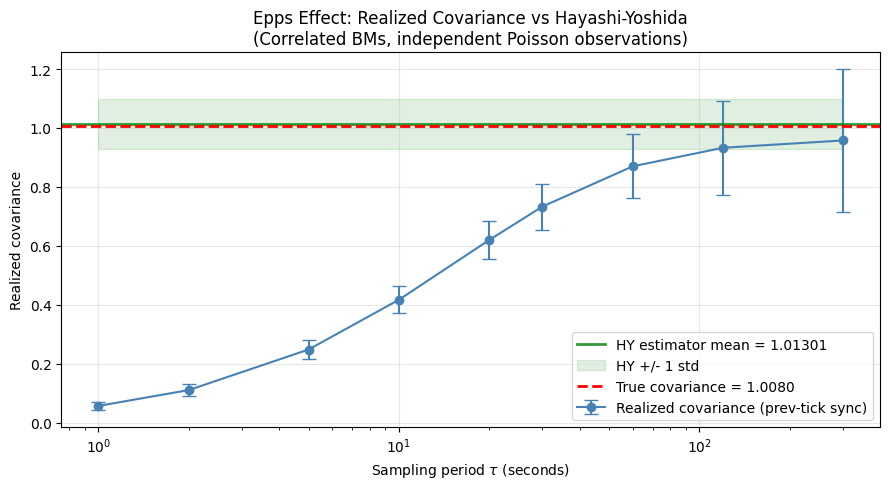


   tau (s) |      RC mean |     RC std |    RC bias
-------------------------------------------------------
         1 |      0.05777 |    0.01408 |   -0.95023
         2 |      0.11165 |    0.01979 |   -0.89635
         5 |      0.24890 |    0.03286 |   -0.75910
        10 |      0.41778 |    0.04496 |   -0.59022
        20 |      0.62072 |    0.06365 |   -0.38728
        30 |      0.73348 |    0.07806 |   -0.27452
        60 |      0.87012 |    0.10911 |   -0.13788
       120 |      0.93303 |    0.16006 |   -0.07497
       300 |      0.95772 |    0.24169 |   -0.05028

        HY |      1.01301 |    0.08479 |    0.00501


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(tau_values, rcov_means, yerr=rcov_stds, fmt='o-',
            color='steelblue', capsize=5, label='Realized covariance (prev-tick sync)')

ax.axhline(hy_mean, color='green', linestyle='-', lw=2, alpha=0.8,
           label=f'HY estimator mean = {hy_mean:.5f}')
ax.fill_between(tau_values, hy_mean - hy_std, hy_mean + hy_std,
                color='green', alpha=0.12, label='HY +/- 1 std')

ax.axhline(true_cov, color='red', linestyle='--', lw=2,
           label=f'True covariance = {true_cov:.4f}')

ax.set_xscale('log')
ax.set_xlabel(r'Sampling period $\tau$ (seconds)')
ax.set_ylabel('Realized covariance')
ax.set_title('Epps Effect: Realized Covariance vs Hayashi-Yoshida\n'
             '(Correlated BMs, independent Poisson observations)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'tau (s)':>10} | {'RC mean':>12} | {'RC std':>10} | {'RC bias':>10}")
print('-' * 55)
for tau, m, s in zip(tau_values, rcov_means, rcov_stds):
    print(f"{tau:>10} | {m:>12.5f} | {s:>10.5f} | {m - true_cov:>10.5f}")
print(f"\n{'HY':>10} | {hy_mean:>12.5f} | {hy_std:>10.5f} | {hy_mean - true_cov:>10.5f}")

The plot perfectly demonstrates the Epps effect, the standard estimator starts near 0 at small $\tau$ and only recovers the true covariance ($\sim 1.008$) at very coarse sampling ($\tau \approx 300$), while the HY estimator immediately delivers an unbiased estimate (mean=1.013) independently of $\tau$, confirming its consistency under asynchronous observations.

We also show numerically that the estimator is consistent: $$ U_n \xrightarrow[n \xrightarrow{} +\infty]{\mathbb{P}} \int_0^T \sigma_1 (t) \sigma_2 (t) \rho (t) dt $$

Intensities: 100%|██████████| 7/7 [09:58<00:00, 85.43s/it] 


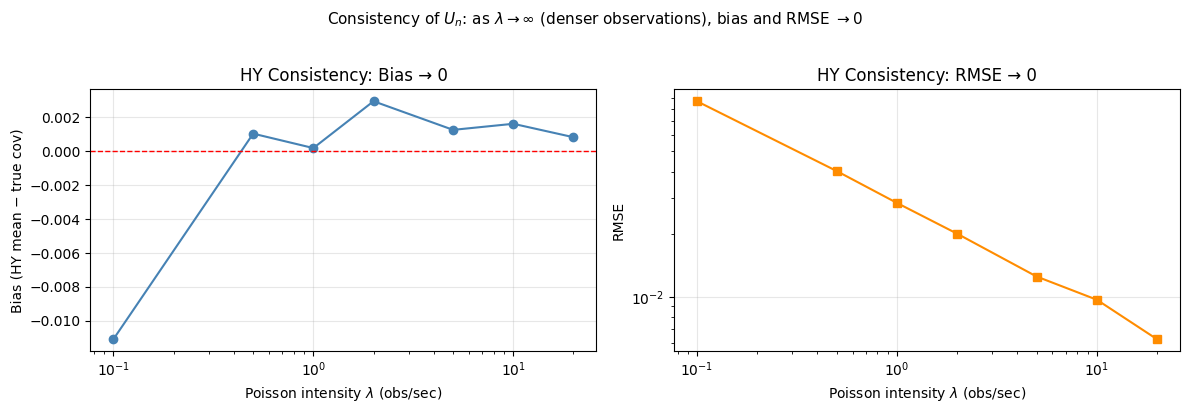

    lambda |         Bias |         RMSE
----------------------------------------
       0.1 |    -0.011082 |     0.087025
       0.5 |     0.001040 |     0.040226
       1.0 |     0.000189 |     0.028285
       2.0 |     0.002951 |     0.020131
       5.0 |     0.001262 |     0.012533
      10.0 |     0.001620 |     0.009697
      20.0 |     0.000829 |     0.006267


In [23]:
intensities = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
# intensities = [0.1, 5.0, 20.0]
n_mc = 100
rng_seed = 123

hy_bias = []
hy_rmse = []

for lam in tqdm(intensities, desc="Intensities"):
    sims = simulate_poisson_sampled_bm(T_BM, sigma1, sigma2, rho, lam, lam,
                                       n_paths=n_mc, seed=rng_seed)
    covs = np.array([hayashi_yoshida(*p) for p in sims])
    hy_bias.append(np.mean(covs) - true_cov)
    hy_rmse.append(np.sqrt(np.mean((covs - true_cov)**2)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(intensities, hy_bias, 'o-', color='steelblue')
ax1.axhline(0, color='red', ls='--', lw=1)
ax1.set_xlabel(r'Poisson intensity $\lambda$ (obs/sec)')
ax1.set_ylabel('Bias (HY mean − true cov)')
ax1.set_title('HY Consistency: Bias → 0')
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)

ax2.plot(intensities, hy_rmse, 's-', color='darkorange')
ax2.set_xlabel(r'Poisson intensity $\lambda$ (obs/sec)')
ax2.set_ylabel('RMSE')
ax2.set_title('HY Consistency: RMSE → 0')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.suptitle(r'Consistency of $U_n$: as $\lambda \to \infty$ (denser observations), bias and RMSE $\to 0$',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f"{'lambda':>10} | {'Bias':>12} | {'RMSE':>12}")
print('-' * 40)
for lam, b, r in zip(intensities, hy_bias, hy_rmse):
    print(f"{lam:>10.1f} | {b:>12.6f} | {r:>12.6f}")

As the observation intensity increases, the Hayashi–Yoshida estimator becomes more accurate. Both the bias and the RMSE decrease and tend to zero, illustrating the consistency of the estimator when observations become dense.
Bias even becomes slightly positive for $\lambda = 10$. That is normal and due to Monte Carlo noise (finite number of simulations)

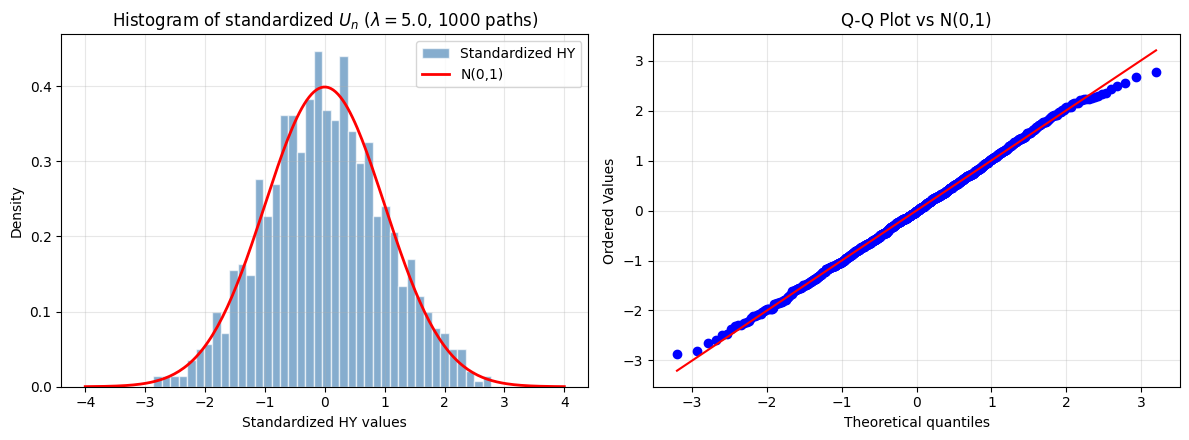

Shapiro-Wilk test:  statistic = 0.9983,  p-value = 0.4131
Jarque-Bera test:   statistic = 2.7466,  p-value = 0.2533

Skewness:  0.0303
Kurtosis:  -0.2495  (excess, should be ≈ 0 for Gaussian)

=> Both tests fail to reject normality at the 5% level: consistent with asymptotic Gaussianity.


In [9]:
lam_test = 5.0
n_mc_gauss = 1000
sims_gauss = simulate_poisson_sampled_bm(T_BM, sigma1, sigma2, rho,
                                         lam_test, lam_test,
                                         n_paths=n_mc_gauss, seed=456)
hy_vals = np.array([hayashi_yoshida(*p) for p in sims_gauss])

hy_centered = hy_vals - np.mean(hy_vals)
hy_standardized = hy_centered / np.std(hy_vals)

# tests
shapiro_stat, shapiro_p = stats.shapiro(hy_standardized)
jb_stat, jb_p = stats.jarque_bera(hy_standardized)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.hist(hy_standardized, bins=40, density=True, alpha=0.65, color='steelblue',
         edgecolor='white', label='Standardized HY')
x_grid = np.linspace(-4, 4, 200)
ax1.plot(x_grid, stats.norm.pdf(x_grid), 'r-', lw=2, label='N(0,1)')
ax1.set_xlabel('Standardized HY values')
ax1.set_ylabel('Density')
ax1.set_title(f'Histogram of standardized $U_n$ ($\\lambda={lam_test}$, {n_mc_gauss} paths)')
ax1.legend()
ax1.grid(True, alpha=0.3)

stats.probplot(hy_standardized, dist='norm', plot=ax2)
ax2.set_title('Q-Q Plot vs N(0,1)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Shapiro-Wilk test:  statistic = {shapiro_stat:.4f},  p-value = {shapiro_p:.4f}")
print(f"Jarque-Bera test:   statistic = {jb_stat:.4f},  p-value = {jb_p:.4f}")
print(f"\nSkewness:  {stats.skew(hy_standardized):.4f}")
print(f"Kurtosis:  {stats.kurtosis(hy_standardized):.4f}  (excess, should be ≈ 0 for Gaussian)")
if shapiro_p > 0.05 and jb_p > 0.05:
    print("\n=> Both tests fail to reject normality at the 5% level: consistent with asymptotic Gaussianity.")
else:
    print(f"\n=> Normality {'not rejected by Shapiro-Wilk' if shapiro_p > 0.05 else 'rejected by Shapiro-Wilk'} "
          f"and {'not rejected by Jarque-Bera' if jb_p > 0.05 else 'rejected by Jarque-Bera'} at 5%."
          f"\n   With finite samples, slight deviations are expected. The CLT is an *asymptotic* result.")

The histogram and Q–Q plot show that the standardized Hayashi–Yoshida estimator is close to a $\mathcal{N}(0,1)$ distribution. The normality tests (Shapiro–Wilk and Jarque–Bera) fail to reject Gaussianity, supporting the asymptotic normality predicted by theory.

# **Question2 : signature and epps effect**

In [11]:
from itertools import combinations

def realized_variance(times, prices, tau, T):
    """Prev-tick realized variance at sampling period tau."""
    grid = np.arange(0, T + tau, tau)
    idx  = np.clip(np.searchsorted(times, grid, side='right') - 1, 0, len(prices) - 1)
    return float(np.sum(np.diff(prices[idx]) ** 2))

def realized_covariance_sync(times1, prices1, times2, prices2, tau, T):
    """Prev-tick realized covariance at sampling period tau."""
    grid = np.arange(0, T + tau, tau)
    def pt(t, p):
        return p[np.clip(np.searchsorted(t, grid, side='right') - 1, 0, len(p)-1)]
    return float(np.sum(np.diff(pt(times1, prices1)) * np.diff(pt(times2, prices2))))

def std_correlation(times1, prices1, times2, prices2, tau, T):
    rv1  = realized_variance(times1, prices1, tau, T)
    rv2  = realized_variance(times2, prices2, tau, T)
    rcov = realized_covariance_sync(times1, prices1, times2, prices2, tau, T)
    return rcov / np.sqrt(rv1 * rv2) if rv1 * rv2 > 0 else np.nan

def hy_corr(times1, prices1, times2, prices2):
    """HY correlation – reuses hayashi_yoshida() from Q1."""
    cov = hayashi_yoshida(times1, prices1, times2, prices2)
    rv1 = np.sum(np.diff(prices1) ** 2)
    rv2 = np.sum(np.diff(prices2) ** 2)
    return cov / np.sqrt(rv1 * rv2) if rv1 * rv2 > 0 else np.nan

In [29]:
TIME_COL  = 'ts'    # seconds from session open (or Unix time)
PRICE_COL = 'price'
def get_single_day_series(stock_id, day_id):
    df = trades[day_id, stock_id][[TIME_COL, PRICE_COL]].dropna().sort_values(TIME_COL)
    t  = pd.to_datetime(df[TIME_COL])
    t  = (t - t.iloc[0]).dt.total_seconds().values
    p  = np.log(df[PRICE_COL].values.astype(float))
    return t, p

tau_values =np.arange(1, 50, 1).astype(float)# [1, 5, 10, 30, 60, 120, 300, 600, 900, 1800]
colors     = ['steelblue', 'darkorange', 'seagreen']

## Mean signature plot 

For each stock, the per-interval realized variance $\hat{C}(\tau)$ is computed at each sampling period $\tau$ across all 5 days independently, then averaged to produce the mean signature plot with a $\pm 1$ std confidence band reflecting day-to-day variability.

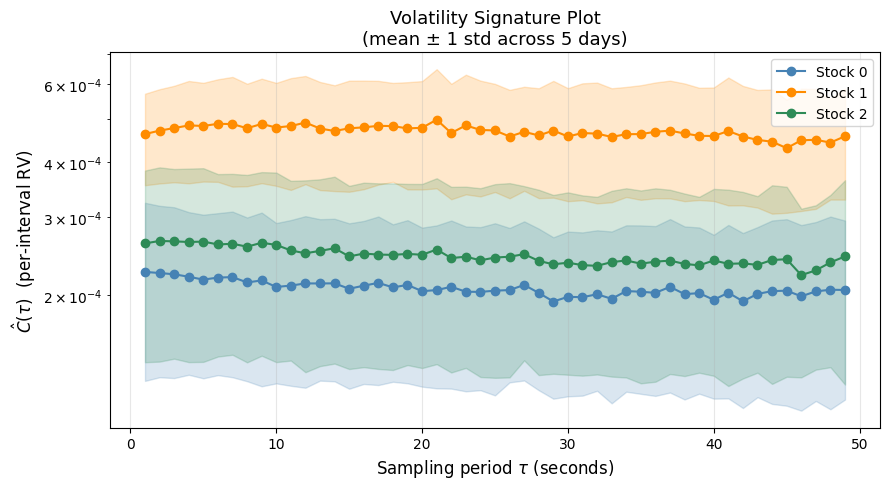

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))

for i in range(3):
    rv_per_day = []
    for j in range(5):
        t, p  = get_single_day_series(i, j)
        T_day = t[-1] - t[0]
        rvs   = [realized_variance(t, p, tau, T_day) for tau in tau_values]
        rv_per_day.append(rvs)

    rv_arr  = np.array(rv_per_day)        # shape (5, len(tau_values))
    mean_rv = rv_arr.mean(axis=0)
    std_rv  = rv_arr.std(axis=0)

    ax.plot(tau_values, mean_rv, 'o-', color=colors[i], label=f'Stock {i}')
    ax.fill_between(tau_values,
                    mean_rv - std_rv,
                    mean_rv + std_rv,
                    alpha=0.2, color=colors[i])

ax.set_yscale('log')
ax.set_xlabel(r'Sampling period $\tau$ (seconds)', fontsize=12)
ax.set_ylabel(r'$\hat{C}(\tau)$  (per-interval RV)', fontsize=12)
ax.set_title('Volatility Signature Plot\n(mean ± 1 std across 5 days)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The signature plot shows that realized vol increases with $\tau$ as expected, with Stock 1 being clearly the most volatile and showing the highest day-to-day variability (wide orange band). 

The curves are nearly flat for  $\tau<30s$ due to sparse trading, at high frequencies most grid points inherit the same prev-tick price, and only diverge meaningfully beyond $\tau\approx300s$ where genuine price diffusion becomes detectable.

## Epss effect for correlation

For each stock pair, both the standard correlation (at each $\tau$) and the HY correlation are computed day by day, then averaged across the 5 days to plot the Epps effect with a $\pm 1$ std confidence band.

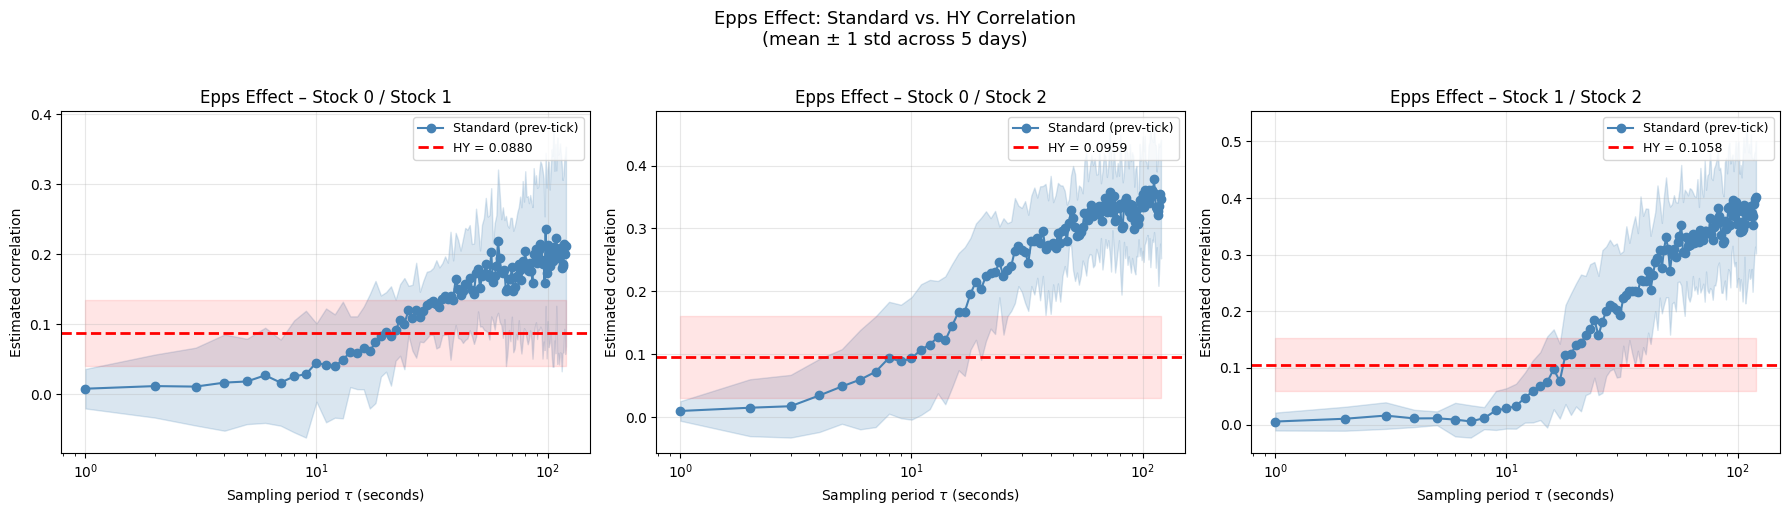

=== Per-day HY correlation (mean ± std) ===
  Stock 0 / Stock 1: 0.0880 ± 0.0471  | per day: ['0.0894', '0.1708', '0.0923', '0.0567', '0.0311']
  Stock 0 / Stock 2: 0.0959 ± 0.0654  | per day: ['0.1945', '0.0856', '-0.0012', '0.0677', '0.1329']
  Stock 1 / Stock 2: 0.1058 ± 0.0464  | per day: ['0.0843', '0.1599', '0.1035', '0.0320', '0.1494']


In [14]:


pairs      = list(combinations(range(3), 2))
pair_names = [f'Stock {i} / Stock {j}' for i, j in pairs]

fig, axes = plt.subplots(1, len(pairs), figsize=(6 * len(pairs), 5), sharey=False)

for ax, (si, sj), name in zip(axes, pairs, pair_names):

    hy_per_day  = []
    std_per_day = []   # shape will be (5, len(tau_values))

    for j in range(5):
        ti, pi = get_single_day_series(si, j)
        tj, pj = get_single_day_series(sj, j)
        T_day  = min(ti[-1], tj[-1])

        hy_per_day.append(hy_corr(ti, pi, tj, pj))
        std_per_day.append([
            std_correlation(ti, pi, tj, pj, tau, T_day)
            for tau in tau_values
        ])

    # HY: mean and std across days
    hy_mean = np.mean(hy_per_day)
    hy_std  = np.std(hy_per_day)

    # Standard: mean and std across days
    std_arr  = np.array(std_per_day)   # (5, len(tau_values))
    std_mean = np.nanmean(std_arr, axis=0)
    std_std  = np.nanstd(std_arr, axis=0)

    # Plot standard estimator
    ax.plot(tau_values, std_mean, 'o-', color='steelblue',
            label='Standard (prev-tick)')
    ax.fill_between(tau_values,
                    std_mean - std_std,
                    std_mean + std_std,
                    alpha=0.2, color='steelblue')

    # Plot HY as horizontal band
    ax.axhline(hy_mean, color='red', lw=2, linestyle='--',
               label=f'HY = {hy_mean:.4f}')
    ax.fill_between(tau_values,
                    [hy_mean - hy_std] * len(tau_values),
                    [hy_mean + hy_std] * len(tau_values),
                    color='red', alpha=0.10)

    ax.set_xscale('log')
    ax.set_xlabel(r'Sampling period $\tau$ (seconds)')
    ax.set_ylabel('Estimated correlation')
    ax.set_title(f'Epps Effect – {name}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Epps Effect: Standard vs. HY Correlation\n(mean ± 1 std across 5 days)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Numeric summary ───────────────────────────────────────────────────────────
print("=== Per-day HY correlation (mean ± std) ===")
for (si, sj), name in zip(pairs, pair_names):
    vals = [hy_corr(*get_single_day_series(si, j),
                    *get_single_day_series(sj, j)) for j in range(5)]
    print(f"  {name}: {np.mean(vals):.4f} ± {np.std(vals):.4f}  "
          f"| per day: {[f'{v:.4f}' for v in vals]}")

The Epps effect is clearly visible, the standard estimator rises from $\sim 0$ at small $\tau$ confirming asynchronicity bias, but overshoots the HY baseline ($\sim 0.09$–$0.11$) at large $\tau$, and the high day-to-day variability in HY estimates reveals significant non-stationarity in the correlation structure across days.

# **Question3 : Lead-lag**

=== Lead-Lag Estimates (per day) ===

  Stock 0 / Stock 1:
    Best lag (mean curve): -10s
    Per-day best lags:     ['10s', '-1s', '-3s', '-10s', '-10s']
    Interpretation:        Stock 1 leads Stock 0

  Stock 0 / Stock 2:
    Best lag (mean curve): -3s
    Per-day best lags:     ['-1s', '10s', '-15s', '15s', '-4s']
    Interpretation:        Stock 2 leads Stock 0

  Stock 1 / Stock 2:
    Best lag (mean curve): 10s
    Per-day best lags:     ['-20s', '10s', '-10s', '25s', '10s']
    Interpretation:        Stock 1 leads Stock 2


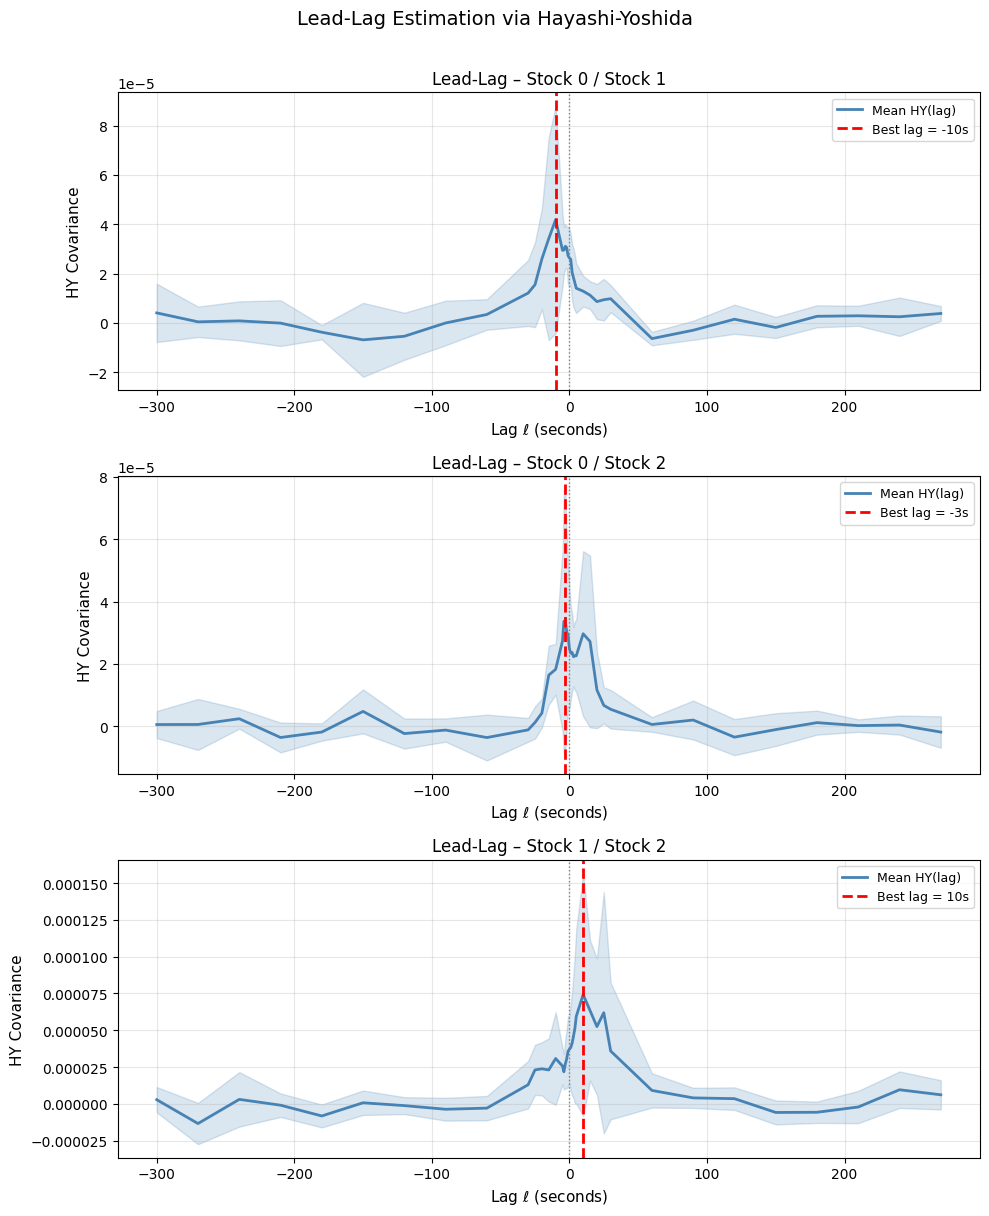

In [ ]:
def hayashi_yoshida_lagged(times1, prices1, times2, prices2, lag):
    """
    HY covariance with times2 shifted by lag seconds.
    Positive lag = Stock 2 is delayed = Stock 1 leads.
    """
    return hayashi_yoshida(times1, prices1, times2 + lag, prices2)


# Lead-lag estimation
# Lags to test (in seconds) – fine grid around 0
lags = np.concatenate([
    np.arange(-300, -30, 30),
    np.arange(-30, -5, 5),
    np.arange(-5, 5, 1),       # fine resolution near 0
    np.arange(5, 30, 5),
    np.arange(30, 300, 30)
])

pairs      = list(combinations(range(3), 2))
pair_names = [f'Stock {i} / Stock {j}' for i, j in pairs]

fig, axes = plt.subplots(len(pairs), 1,
                         figsize=(10, 4 * len(pairs)))

print("=== Lead-Lag Estimates (per day) ===")

for ax, (si, sj), name in zip(axes, pairs, pair_names):

    lag_estimates = []
    all_hy_curves = []

    for j in range(5):
        ti, pi = get_single_day_series(si, j)
        tj, pj = get_single_day_series(sj, j)

        # HY covariance for each lag
        hy_curve = np.array([
            hayashi_yoshida_lagged(ti, pi, tj, pj, lag)
            for lag in lags
        ])
        all_hy_curves.append(hy_curve)

        # Best lag for this day
        best_lag = lags[np.argmax(hy_curve)]
        lag_estimates.append(best_lag)

    # Average curve across days
    mean_curve = np.mean(all_hy_curves, axis=0)
    std_curve  = np.std(all_hy_curves,  axis=0)
    best_lag_mean = lags[np.argmax(mean_curve)]

    ax.plot(lags, mean_curve, color='steelblue', lw=2, label='Mean HY(lag)')
    ax.fill_between(lags,
                    mean_curve - std_curve,
                    mean_curve + std_curve,
                    alpha=0.2, color='steelblue')
    ax.axvline(best_lag_mean, color='red', lw=2, linestyle='--',
               label=f'Best lag = {best_lag_mean:.0f}s')
    ax.axvline(0, color='gray', lw=1, linestyle=':')
    ax.set_xlabel('Lag $\\ell$ (seconds)', fontsize=11)
    ax.set_ylabel('HY Covariance', fontsize=11)
    ax.set_title(f'Lead-Lag – {name}', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    print(f"\n  {name}:")
    print(f"    Best lag (mean curve): {best_lag_mean:.0f}s")
    print(f"    Per-day best lags:     {[f'{l:.0f}s' for l in lag_estimates]}")
    direction = (f"Stock {si} leads Stock {sj}" if best_lag_mean > 0
                 else f"Stock {sj} leads Stock {si}" if best_lag_mean < 0
                 else "No lead-lag detected")
    print(f"    Interpretation:        {direction}")

plt.suptitle('Lead-Lag Estimation via Hayashi-Yoshida', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

All three pairs show a sharp peak very close to lag 0 (within $\pm 10$ seconds), indicating that the stocks react to common information nearly simultaneously with no strong lead-lag structure. The small detected lags ($-10s$, $-3s$, $+10s$) are close to zero and inconsistent in direction across pairs, suggesting they reflect estimation noise rather than a genuine systematic leadership relationship between any of the three stocks.

# **Question4 : hawkes process**

In [ ]:
from numba import njit, prange
from scipy.optimize import minimize, differential_evolution
from scipy.stats import kstest
import warnings
from joblib import Parallel, delayed

# Numba kernels

@njit
def _ll_exp1(mu, alpha, beta, times, T):
    n = len(times)
    A = 0.0; ll = 0.0
    for i in range(n):
        if i > 0:
            A = np.exp(-beta*(times[i]-times[i-1]))*(1.0+A)
        lam = mu + alpha*A
        if lam <= 0: return -1e10
        ll += np.log(lam)
    integral = mu*T
    for i in range(n):
        integral += (alpha/beta)*(1.0 - np.exp(-beta*(T-times[i])))
    return ll - integral

@njit
def _comp_exp1(mu, alpha, beta, times):
    n = len(times); taus = np.zeros(n-1); A = 0.0
    for i in range(1, n):
        dt = times[i]-times[i-1]
        taus[i-1] = mu*dt + (alpha/beta)*A*(1.0-np.exp(-beta*dt))
        A = np.exp(-beta*dt)*(A+1.0)
    return taus

@njit
def _ll_exp2(mu, a1, b1, a2, b2, times, T):
    n = len(times)
    A1 = 0.0; A2 = 0.0; ll = 0.0
    for i in range(n):
        if i > 0:
            dt = times[i]-times[i-1]
            A1 = np.exp(-b1*dt)*(1.0+A1)
            A2 = np.exp(-b2*dt)*(1.0+A2)
        lam = mu + a1*A1 + a2*A2
        if lam <= 0: return -1e10
        ll += np.log(lam)
    integral = mu*T
    for i in range(n):
        integral += (a1/b1)*(1.0-np.exp(-b1*(T-times[i])))
        integral += (a2/b2)*(1.0-np.exp(-b2*(T-times[i])))
    return ll - integral

@njit
def _comp_exp2(mu, a1, b1, a2, b2, times):
    n = len(times); taus = np.zeros(n-1)
    A1 = 0.0; A2 = 0.0
    for i in range(1, n):
        dt = times[i]-times[i-1]
        taus[i-1] = (mu*dt
                     + (a1/b1)*A1*(1.0-np.exp(-b1*dt))
                     + (a2/b2)*A2*(1.0-np.exp(-b2*dt)))
        A1 = np.exp(-b1*dt)*(A1+1.0)
        A2 = np.exp(-b2*dt)*(A2+1.0)
    return taus

# Warm up
_d = np.linspace(0.1, 5.0, 10)
_ll_exp1(0.1,0.3,1.0,_d,5.0)
_ll_exp2(0.1,0.2,2.0,0.1,0.5,_d,5.0)
_comp_exp1(0.1,0.3,1.0,_d)
_comp_exp2(0.1,0.2,2.0,0.1,0.5,_d)

Numba kernels compiled.


In [ ]:
MAX_N = 3000   # subsampling cap

def subsample(t, max_n=MAX_N):
    if len(t) <= max_n: return t.astype(np.float64)
    idx = np.linspace(0, len(t)-1, max_n).astype(int)
    return t[idx].astype(np.float64)

def pool_all_days(stock_id):
    """Concatenate all days with large gap between them."""
    all_t = []
    offset = 0.0
    for j in range(5):
        t, _ = get_single_day_series(stock_id, j)
        gap   = 10 * np.max(np.diff(t))
        all_t.append(t + offset)
        offset += t[-1] + gap
    times = np.concatenate(all_t)
    T     = times[-1]
    return subsample(times), T

def fit_poisson(times, T):
    lam  = len(times) / T
    taus = lam * np.diff(times)
    _, p = kstest(taus, 'expon')
    return dict(lam=lam, taus=taus, pval=p, br=0.0)

def fit_exp1(times, T):
    best = None
    for mu0 in [0.01, 0.05, 0.1]:
        for a0 in [0.1, 0.4, 0.7]:
            for b0 in [0.5, 2.0, 8.0]:
                def neg(p):
                    if p[0]<=0 or p[1]<=0 or p[2]<=0: return 1e10
                    if p[1]/p[2] >= 1: return 1e10
                    return -_ll_exp1(p[0],p[1],p[2], times, T)
                res = minimize(neg, [mu0,a0,b0],
                               method='L-BFGS-B',
                               bounds=[(1e-6,None)]*3)
                if best is None or res.fun < best.fun:
                    best = res
    mu,a,b = best.x
    taus   = _comp_exp1(mu,a,b,times); taus = taus[taus>0]
    _,p    = kstest(taus,'expon')
    return dict(params=best.x, br=a/b, taus=taus, pval=p)

def fit_exp2(times, T):
    best = None
    for mu0 in [0.01, 0.1]:
        for a1 in [0.1, 0.3]:
            for b1 in [2.0, 8.0]:     # fast kernel
                for a2 in [0.1, 0.3]:
                    for b2 in [0.1, 0.5]:   # slow kernel
                        def neg(p):
                            if any(x<=0 for x in p): return 1e10
                            if p[1]/p[2]+p[3]/p[4] >= 1: return 1e10
                            return -_ll_exp2(p[0],p[1],p[2],
                                             p[3],p[4],times,T)
                        res = minimize(neg, [mu0,a1,b1,a2,b2],
                                       method='L-BFGS-B',
                                       bounds=[(1e-6,None)]*5)
                        if best is None or res.fun < best.fun:
                            best = res
    mu,a1,b1,a2,b2 = best.x
    br   = a1/b1 + a2/b2
    taus = _comp_exp2(mu,a1,b1,a2,b2,times); taus = taus[taus>0]
    _,p  = kstest(taus,'expon')
    return dict(params=best.x, br=br, taus=taus, pval=p)


def fit_all_models_for_stock(stock_id):
    """Fit all 3 models for one stock — this is what gets parallelized."""
    print(f"  Fitting Stock {stock_id}...")
    times, T = pool_all_days(stock_id)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        r_pois = fit_poisson(times, T)
        r_exp1 = fit_exp1(times, T)
        r_exp2 = fit_exp2(times, T)
    print(f"  Stock {stock_id} done. "
          f"br1={r_exp1['br']:.3f}  br2={r_exp2['br']:.3f}  "
          f"p1={r_exp1['pval']:.4f}  p2={r_exp2['pval']:.4f}")
    return stock_id, r_pois, r_exp1, r_exp2


# Run in parallel across stocks
print("Fitting all stocks in parallel...\n")

job_results = Parallel(n_jobs=3, prefer='threads')(
    delayed(fit_all_models_for_stock)(i) for i in range(3)
)

# Unpack results
global_pois = {}
global_exp1 = {}
global_exp2 = {}
for stock_id, rp, r1, r2 in sorted(job_results):
    global_pois[stock_id] = rp
    global_exp1[stock_id] = r1
    global_exp2[stock_id] = r2

print("\nAll done.")

Fitting all stocks in parallel...

  Fitting Stock 0...
  Fitting Stock 1...
  Fitting Stock 2...
  Stock 0 done. br1=0.006  br2=0.006  p1=0.0000  p2=0.0000
  Stock 2 done. br1=0.015  br2=0.833  p1=0.0000  p2=0.0000
  Stock 1 done. br1=0.040  br2=0.777  p1=0.0000  p2=0.0000

All done.


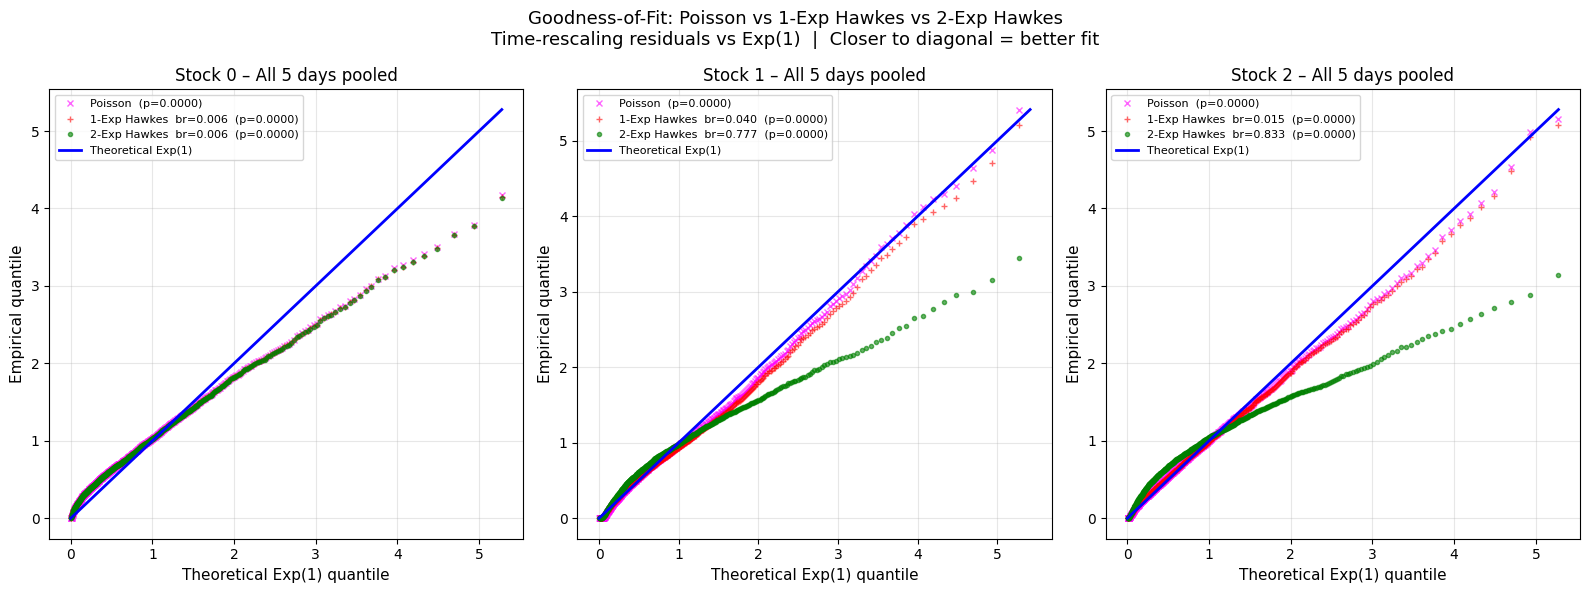

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Shared theoretical quantiles
q_th = np.quantile(
    np.random.exponential(1, 200_000),
    np.linspace(0.005, 0.995, 500)
)

for i in range(3):
    ax = axes[i]

    models = [
        ('Poisson',      global_pois[i]['taus'], 'magenta', 'x',  4),
        ('1-Exp Hawkes', global_exp1[i]['taus'], 'red',     '+',  4),
        ('2-Exp Hawkes', global_exp2[i]['taus'], 'green',   'o',  3),
    ]

    x_max = 0
    for label, taus, color, marker, ms in models:
        q_emp = np.quantile(taus, np.linspace(0.005, 0.995, 500))
        pval  = (global_pois[i]['pval']  if 'Poisson' in label else
                 global_exp1[i]['pval']  if '1-Exp'   in label else
                 global_exp2[i]['pval'])
        br    = (global_exp1[i]['br']    if '1-Exp'   in label else
                 global_exp2[i]['br']    if '2-Exp'   in label else None)
        br_str = f'  br={br:.3f}' if br is not None else ''
        ax.plot(q_th, q_emp,
                marker=marker, color=color, ms=ms,
                alpha=0.6, linestyle='none',
                label=f'{label}{br_str}  (p={pval:.4f})')
        x_max = max(x_max, q_th.max(), q_emp.max())

    # Diagonal
    diag = np.linspace(0, x_max, 200)
    ax.plot(diag, diag, '-', color='blue', lw=2, label='Theoretical Exp(1)')

    ax.set_xlabel('Theoretical Exp(1) quantile', fontsize=11)
    ax.set_ylabel('Empirical quantile',           fontsize=11)
    ax.set_title(f'Stock {i} - All 5 days pooled', fontsize=12)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.suptitle(
    'Goodness-of-Fit: Poisson vs 1-Exp Hawkes vs 2-Exp Hawkes\n'
    'Time-rescaling residuals vs Exp(1)  |  Closer to diagonal = better fit',
    fontsize=13
)
plt.tight_layout()
plt.show()

All three models are formally rejected ($p=0.000$), but visually the 1-Exp Hawkes modestly improves over Poisson for Stocks 1 and 2, while the 2-Exp Hawkes collapses to unrealistic high branching ratios ($br \approx 0.8$) indicating numerical instability and overfitting. The very low branching ratios of the 1-Exp fits ($br \approx 0.006–0.04$) suggest trades are predominantly exogenous with weak self-excitation, and a power-law kernel would likely be needed to fully capture the long-memory clustering structure observed in real microstructure data.

# **Question5 : signature hawked fitting**

Raw RV computed.
  Stock 0: RV(1s)=2.258e-04  RV(60s)=1.713e-04  RV(max)=1.713e-04
  Stock 1: RV(1s)=4.626e-04  RV(60s)=5.076e-04  RV(max)=5.076e-04
  Stock 2: RV(1s)=2.619e-04  RV(60s)=2.293e-04  RV(max)=2.293e-04

Stock  Method      │     α/β│       κ│   1/γ(s)│           Λ│ Verdict
  0    Uniform     │  0.1071│  0.9033│    30.95│   7.218e-09│ ✓✓ very good
  0    U-shaped    │  0.1094│  0.9014│    18.36│   7.346e-09│ ✓✓ very good
------------------------------------------------------------------------
  1    Uniform     │  0.0000│  1.0000│     0.01│   1.573e-08│ ⚠ poor
  1    U-shaped    │  0.0000│  1.0000│     0.01│   1.582e-08│ ⚠ poor
------------------------------------------------------------------------
  2    Uniform     │  0.0808│  0.9253│     8.14│   8.864e-09│ ✓✓ very good
  2    U-shaped    │  0.0758│  0.9295│    12.24│   8.779e-09│ ✓✓ very good
------------------------------------------------------------------------


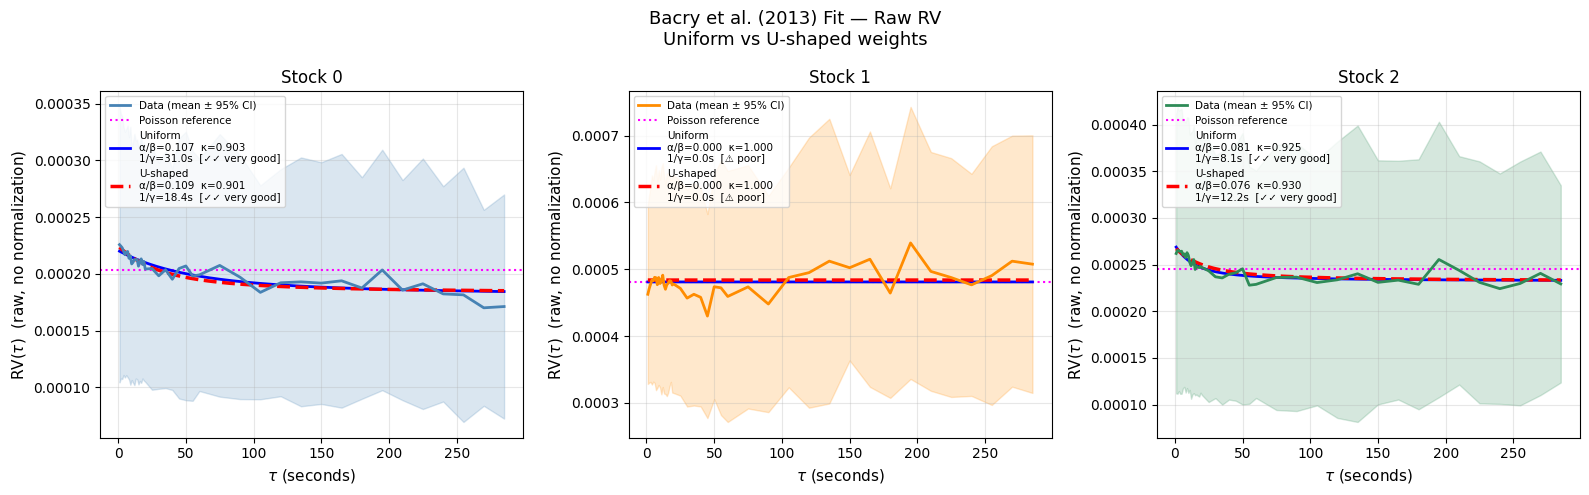

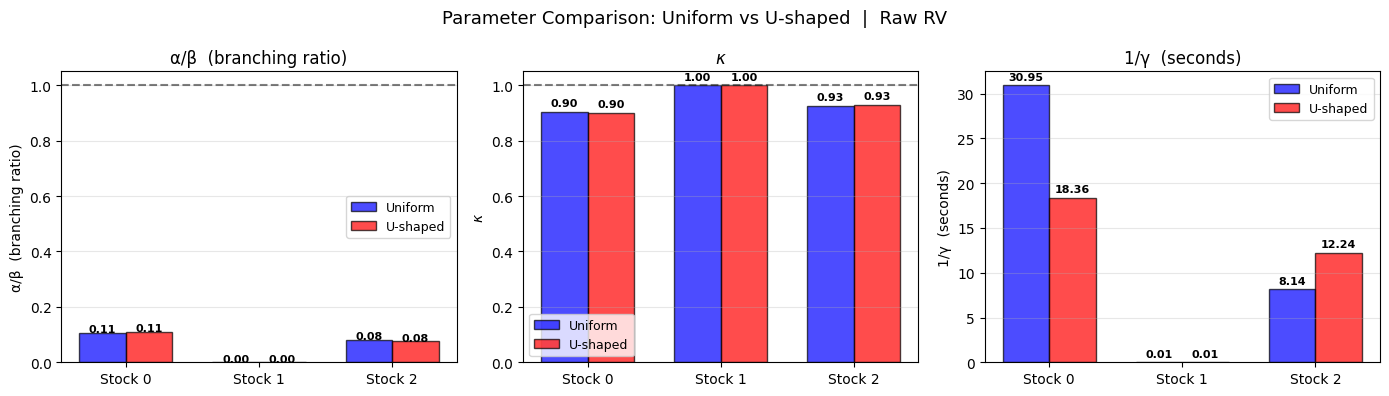

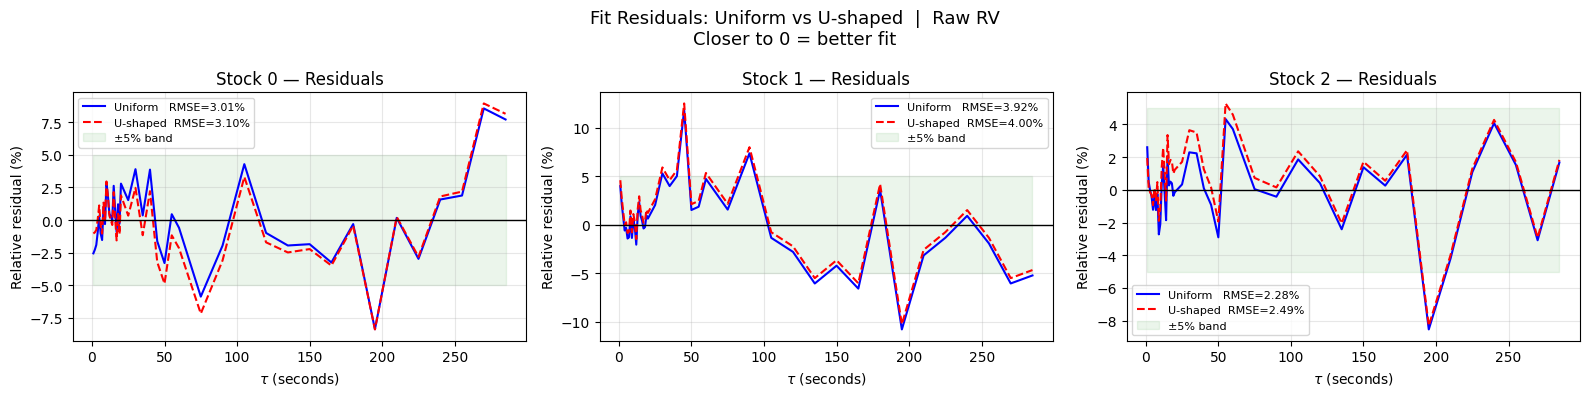


FULL PARAMETER TABLE — RAW RV, BOTH WEIGHTINGS
Stock Method        │     α/β│       κ│   1/γ(s)│           Λ│ Verdict
---------------------------------------------------------------------------
  0    Uniform       │  0.1071│  0.9033│    30.95│   7.218e-09│ ✓✓ very good
  0    U-shaped      │  0.1094│  0.9014│    18.36│   7.346e-09│ ✓✓ very good
---------------------------------------------------------------------------
  1    Uniform       │  0.0000│  1.0000│     0.01│   1.573e-08│ ⚠ poor
  1    U-shaped      │  0.0000│  1.0000│     0.01│   1.582e-08│ ⚠ poor
---------------------------------------------------------------------------
  2    Uniform       │  0.0808│  0.9253│     8.14│   8.864e-09│ ✓✓ very good
  2    U-shaped      │  0.0758│  0.9295│    12.24│   8.779e-09│ ✓✓ very good
---------------------------------------------------------------------------

BEST PARAMETERS PER STOCK  (auto-selected by score)

Stock 0  [best: Uniform  |  verdict: ✓✓ very good]
  α/β = 0.1071  →  mos

In [ ]:
from scipy.stats import t as t_dist
from scipy.optimize import least_squares
import warnings

# HELPERS

def extract_params(lam0, alpha, beta):
    """Convert raw (lam0, alpha, beta) into full parameter dictionary."""
    ratio  = alpha / beta
    kappa  = 1 / (1 + ratio)
    gamma  = alpha + beta
    Lambda = 2 * lam0 / (1 - ratio)
    return dict(lam0=lam0, alpha=alpha, beta=beta,
                ratio=ratio, kappa=kappa, gamma=gamma, Lambda=Lambda)


def verdict(r):
    """
    Rate the quality of a fit on 4 criteria.
    Returns a string label from degenerate to very good.
    """
    if r is None: return "FAILED"
    ok_ratio = 0.001 < r['ratio'] < 0.95
    ok_kappa = 0.2   < r['kappa'] < 0.999
    ok_gamma = 0.5   < 1/r['gamma'] < 200
    ok_lam   = r['Lambda'] > 1e-15
    n_ok = sum([ok_ratio, ok_kappa, ok_gamma, ok_lam])
    return ["degenerate",
            "poor",
            "marginal",
            "good",
            "very good"][n_ok]


def score(r):
    """
    Numeric version of verdict — returns 0 to 4.
    Used to automatically select the best fit between two candidates.
      +1 if alpha/beta  in (0.001, 0.95)   stationary and non-trivial
      +1 if kappa    in (0.2,   0.999)  meaningful mean-reversion
      +1 if 1/gamma  in (0.5s,  200s)   physically plausible timescale
      +1 if Lambda    > 1e-15            non-degenerate intensity
    """
    if r is None: return -1
    return sum([
        0.001 < r['ratio'] < 0.95,
        0.2   < r['kappa'] < 0.999,
        0.5   < 1/r['gamma'] < 200,
        r['Lambda'] > 1e-15
    ])


# 1. SETUP

TAU_VALUES = np.concatenate([
    np.arange(1,   20,  1),
    np.arange(20,  60,  5),
    np.arange(60,  300, 15),
]).astype(float)

tau_fine = np.linspace(TAU_VALUES[0], TAU_VALUES[-1], 2000)
colors   = ['steelblue', 'darkorange', 'seagreen']
t_crit   = t_dist.ppf(0.975, df=4)   # 95% CI with 5 days

# 2. EMPIRICAL SIGNATURE — raw RV, no normalization

def sig_raw_rv(times, prices, tau_values):
    """
    Raw realized variance — no normalization.
    RV(tau) = sum_i (p(i*tau) - p((i-1)*tau))^2
    """
    out = []
    for tau in tau_values:
        grid = np.arange(times[0], times[-1] + tau, tau)
        idx  = np.clip(np.searchsorted(times, grid, side='right') - 1,
                       0, len(prices) - 1)
        out.append(float(np.sum(np.diff(prices[idx]) ** 2)))
    return np.array(out)


sig_raw = {}

for i in range(3):
    daily = []
    for j in range(5):
        t, p  = get_single_day_series(i, j)
        T_day = t[-1] - t[0]
        tau_ok = TAU_VALUES[TAU_VALUES < T_day / 2]
        daily.append(sig_raw_rv(t, p, tau_ok))
    min_len = min(len(x) for x in daily)
    arr     = np.array([x[:min_len] for x in daily])
    sig_raw[i] = (arr.mean(0),
                  t_crit * arr.std(0) / np.sqrt(5))

tau_common = TAU_VALUES[:min(len(sig_raw[i][0]) for i in range(3))]

print("Raw RV computed.")
for i in range(3):
    m, _ = sig_raw[i]
    print(f"  Stock {i}: RV(1s)={m[0]:.3e}  "
          f"RV(60s)={m[min(59,len(m)-1)]:.3e}  "
          f"RV(max)={m[-1]:.3e}")

# 3. THEORETICAL FORMULA - raw RV convention

def C_raw(tau, lam0, alpha, beta, T):
    """
    Bacry et al. theoretical signature - raw RV convention.
    C_raw(tau) = T * Lambda * (kappa^2
                               + (1-kappa^2)*(1-exp(-gamma*tau))/(gamma*tau))
    """
    tau   = np.asarray(tau, float)
    ratio = alpha / beta
    if ratio >= 1:
        return np.full_like(tau, 1e10)
    Lambda   = 2 * lam0 / (1 - ratio)
    kappa    = 1 / (1 + ratio)
    gamma    = alpha + beta
    mean_rev = np.where(gamma * tau > 1e-10,
                        (1 - np.exp(-gamma * tau)) / (gamma * tau),
                        1.0)
    return T * Lambda * (kappa**2 + (1 - kappa**2) * mean_rev)

# 4. FIT FUNCTION - uniform and U-shaped weights

def _fit_raw(tau_values, c_hat, T_obs, weight_mode='uniform'):
    """
    Fit (lam0, alpha, beta) on raw RV signature by weighted least squares.

    weight_mode : 'uniform'  — all tau contribute equally
                  'ushaped'  — small tau (identifies gamma) and
                               large tau (identifies Lambda*kappa^2)
                               are upweighted
    """
    scale = c_hat.mean()
    n     = len(tau_values)

    w = np.ones(n)
    if weight_mode == 'ushaped':
        w[:10]  = 3.0
        w[-10:] = 2.0

    def residuals(p):
        lam0, alpha, beta = p
        if alpha / beta >= 0.999:
            return np.full(n, 1e6)
        pred = C_raw(tau_values, lam0, alpha, beta, T_obs)
        if np.any(~np.isfinite(pred)):
            return np.full(n, 1e6)
        return w * (pred - c_hat) / scale

    best, best_cost = None, np.inf

    for lam0_0 in [1e-10, 1e-9, 1e-8, 1e-7, 1e-6]:
        for a0 in [0.01, 0.05, 0.1, 0.3, 0.5, 0.8]:
            for b0 in [0.05, 0.1, 0.5, 1.0, 5.0, 10.0]:
                if a0 / b0 >= 0.999:
                    continue
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        res = least_squares(
                            residuals,
                            x0=[lam0_0, a0, b0],
                            method='trf',
                            bounds=([1e-15, 1e-6, 1e-6],
                                    [1e-3,  0.999, 100.0]),
                            max_nfev=3000,
                            ftol=1e-12, xtol=1e-12
                        )
                    if res.cost < best_cost and res.x[1] / res.x[2] < 1:
                        best_cost = res.cost
                        best      = res
                except Exception:
                    continue

    if best is None:
        return None
    lam0, alpha, beta = best.x
    if alpha / beta >= 1:
        return None
    return lam0, alpha, beta

# 5. RUN BOTH FITS

T_obs = {}
for i in range(3):
    T_obs[i] = np.mean([get_single_day_series(i, j)[0][-1]
                        for j in range(5)])

fits_raw_uniform = {}
fits_raw_ushaped = {}

print(f"\n{'Stock':<6} {'Method':<12}│{'α/β':>8}│{'κ':>8}│"
      f"{'1/γ(s)':>9}│{'Λ':>12}│ Verdict")
print('=' * 72)

for i in range(3):
    mean_c, _ = sig_raw[i]
    tau_use   = tau_common[:len(mean_c)]

    for label, mode, store in [
        ('Uniform',  'uniform',  fits_raw_uniform),
        ('U-shaped', 'ushaped',  fits_raw_ushaped),
    ]:
        result = _fit_raw(tau_use, mean_c, T_obs[i], weight_mode=mode)
        if result is not None:
            r        = extract_params(*result)
            store[i] = r
            print(f"  {i:<4} {label:<12}│{r['ratio']:>8.4f}│{r['kappa']:>8.4f}│"
                  f"{1/r['gamma']:>9.2f}│{r['Lambda']:>12.3e}│ {verdict(r)}")
        else:
            store[i] = None
            print(f"  {i:<4} {label:<12}│ FIT FAILED")
    print('-' * 72)

# 6. MAIN PLOT — both fits on same graph per stock

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i in range(3):
    ax         = axes[i]
    mean_c, ci = sig_raw[i]
    tau_use    = tau_common[:len(mean_c)]
    tau_fine_i = np.linspace(tau_use[0], tau_use[-1], 2000)
    r_u        = fits_raw_uniform.get(i)
    r_s        = fits_raw_ushaped.get(i)

    # Data + 95% CI band
    ax.plot(tau_use, mean_c, '-', color=colors[i], lw=2, zorder=4,
            label='Data (mean ± 95% CI)')
    ax.fill_between(tau_use, mean_c - ci, mean_c + ci,
                    alpha=0.2, color=colors[i])

    # Poisson reference (flat mean)
    ax.axhline(mean_c.mean(), color='magenta', lw=1.5,
               ls=':', label='Poisson reference')

    # Uniform fit
    if r_u:
        c_u = C_raw(tau_fine_i, r_u['lam0'], r_u['alpha'],
                    r_u['beta'], T_obs[i])
        ax.plot(tau_fine_i, c_u, '-', color='blue', lw=2,
                label=f"Uniform\n"
                      f"α/β={r_u['ratio']:.3f}  κ={r_u['kappa']:.3f}\n"
                      f"1/γ={1/r_u['gamma']:.1f}s  [{verdict(r_u)}]")

    # U-shaped fit
    if r_s:
        c_s = C_raw(tau_fine_i, r_s['lam0'], r_s['alpha'],
                    r_s['beta'], T_obs[i])
        ax.plot(tau_fine_i, c_s, '--', color='red', lw=2.5,
                label=f"U-shaped\n"
                      f"α/β={r_s['ratio']:.3f}  κ={r_s['kappa']:.3f}\n"
                      f"1/γ={1/r_s['gamma']:.1f}s  [{verdict(r_s)}]")

    ax.set_xlabel(r'$\tau$ (seconds)', fontsize=11)
    ax.set_ylabel(r'$\mathrm{RV}(\tau)$  (raw, no normalization)', fontsize=11)
    ax.set_title(f'Stock {i}', fontsize=12)
    ax.legend(fontsize=7.5, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.suptitle('Bacry et al. (2013) Fit — Raw RV\n'
             'Uniform vs U-shaped weights', fontsize=13)
plt.tight_layout()
plt.show()

# 7. PARAMETER BAR CHARTS

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x     = np.arange(3)
width = 0.35

def get_val(store, i, param):
    r = store.get(i)
    if r is None: return 0
    return 1/r['gamma'] if param == 'gamma_inv' else r[param]

for col, (param, ylabel, ref) in enumerate([
    ('ratio',     'α/β  (branching ratio)',  1.0),
    ('kappa',     r'$\kappa$',               1.0),
    ('gamma_inv', '1/γ  (seconds)',          None),
]):
    ax     = axes[col]
    vals_u = [get_val(fits_raw_uniform, i, param) for i in range(3)]
    vals_s = [get_val(fits_raw_ushaped, i, param) for i in range(3)]

    b_u = ax.bar(x - width/2, vals_u, width, label='Uniform',
                 color='blue', alpha=0.7, edgecolor='black')
    b_s = ax.bar(x + width/2, vals_s, width, label='U-shaped',
                 color='red',  alpha=0.7, edgecolor='black')

    if ref:
        ax.axhline(ref, color='black', ls='--', lw=1.5, alpha=0.5)

    all_vals = vals_u + vals_s
    for bar, v in zip(list(b_u) + list(b_s), all_vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(all_vals) * 0.02,
                f'{v:.2f}', ha='center', fontsize=8, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels([f'Stock {i}' for i in range(3)])
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Parameter Comparison: Uniform vs U-shaped  |  Raw RV',
             fontsize=13)
plt.tight_layout()
plt.show()

# 8. RESIDUALS

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i in range(3):
    ax        = axes[i]
    mean_c, _ = sig_raw[i]
    tau_use   = tau_common[:len(mean_c)]
    r_u       = fits_raw_uniform.get(i)
    r_s       = fits_raw_ushaped.get(i)

    if r_u:
        pred_u = C_raw(tau_use, r_u['lam0'], r_u['alpha'],
                       r_u['beta'], T_obs[i])
        res_u  = (pred_u - mean_c) / mean_c * 100
        ax.plot(tau_use, res_u, '-', color='blue', lw=1.5,
                label=f'Uniform   RMSE={np.sqrt(np.mean(res_u**2)):.2f}%')

    if r_s:
        pred_s = C_raw(tau_use, r_s['lam0'], r_s['alpha'],
                       r_s['beta'], T_obs[i])
        res_s  = (pred_s - mean_c) / mean_c * 100
        ax.plot(tau_use, res_s, '--', color='red', lw=1.5,
                label=f'U-shaped  RMSE={np.sqrt(np.mean(res_s**2)):.2f}%')

    ax.axhline(0, color='black', lw=1)
    ax.fill_between(tau_use, -5, 5, alpha=0.08,
                    color='green', label='±5% band')
    ax.set_xlabel(r'$\tau$ (seconds)')
    ax.set_ylabel('Relative residual (%)')
    ax.set_title(f'Stock {i} — Residuals')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Fit Residuals: Uniform vs U-shaped  |  Raw RV\n'
             'Closer to 0 = better fit', fontsize=13)
plt.tight_layout()
plt.show()

# 9. FULL SUMMARY TABLE + BEST PARAMETERS

print("\n" + "="*75)
print("FULL PARAMETER TABLE — RAW RV, BOTH WEIGHTINGS")
print("="*75)
print(f"{'Stock':<6}{'Method':<14}│{'α/β':>8}│{'κ':>8}│"
      f"{'1/γ(s)':>9}│{'Λ':>12}│ Verdict")
print("-"*75)

for i in range(3):
    for label, store in [('Uniform',  fits_raw_uniform),
                          ('U-shaped', fits_raw_ushaped)]:
        r = store.get(i)
        if r:
            print(f"  {i:<4} {label:<14}│{r['ratio']:>8.4f}│{r['kappa']:>8.4f}│"
                  f"{1/r['gamma']:>9.2f}│{r['Lambda']:>12.3e}│ {verdict(r)}")
        else:
            print(f"  {i:<4} {label:<14}│{'—':>8}│{'—':>8}│"
                  f"{'—':>9}│{'—':>12}│ FAILED")
    print("-"*75)

print("\n" + "="*75)
print("BEST PARAMETERS PER STOCK  (auto-selected by score)")
print("="*75)

for i in range(3):
    r_u = fits_raw_uniform.get(i)
    r_s = fits_raw_ushaped.get(i)
    r   = r_u if score(r_u) >= score(r_s) else r_s
    nm  = 'Uniform' if score(r_u) >= score(r_s) else 'U-shaped'

    if r is None:
        print(f"\nStock {i}: all fits failed")
        continue

    endo  = ("mostly exogenous"      if r['ratio'] < 0.3 else
             "moderately endogenous" if r['ratio'] < 0.7 else
             "highly endogenous / near-critical")
    noise = ("very strong noise" if r['kappa'] > 0.8 else
             "moderate noise"    if r['kappa'] > 0.5 else
             "weak noise — close to random walk")
    speed = ("very fast" if 1/r['gamma'] < 5  else
             "moderate"  if 1/r['gamma'] < 30 else "slow")

    print(f"\nStock {i}  [best: {nm}  |  verdict: {verdict(r)}]")
    print(f"  α/β = {r['ratio']:.4f}  →  {endo}")
    print(f"  κ   = {r['kappa']:.4f}  →  {noise}")
    print(f"  1/γ = {1/r['gamma']:.2f}s   →  {speed} mean-reversion")
    print(f"  Λ   = {r['Lambda']:.3e} moves/s")
    print(f"  Optimal sampling τ* ≈ {3/r['gamma']:.0f}s  (3/γ rule)")

Stocks 0 and 2 are well fitted by both weighting schemes (RMSE $\sim 2-3\%$) with consistent parameters — low branching ratios ($\alpha/\beta \approx 0.08–0.11$) confirming mostly exogenous price dynamics, strong microstructure noise ($\kappa \approx 0.90–0.93$), and mean-reversion timescales of 8-31 seconds, while Stock 1 fails completely ($\alpha/\beta=0.000$, $1/\gamma=0.01s$) because its nearly flat signature provides insufficient curvature for the optimizer to identify $\gamma$ and $\kappa$ separately. The U-shaped weighting produces slightly more conservative timescales (18s vs 31s for Stock 0, 12s vs 8s for Stock 2) but nearly identical RMSE, confirming that for this dataset both weightings are equivalent and the uniform fit is marginally preferable for Stocks 0 and 2 given its lower residuals.